### Questions for Michael:

- Do we want to remove nodes (and associated edges when a worker is removed)?
- Best network metric(s) to use?
- How to measure project/team diversity?
- Any other metrics to include?

### Interesting results to explore:
 - Slack is higher for Greedy even though team size is larger than RLD2
 - 

### To check:
 - At the moment we are seeing no edges with weights > 1! Is this correct? (e.g. worker turnover so high that there is no opportunity?) Or is there a problem with the network representation?

In [94]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import json
from radar_methods import *
from copy import copy, deepcopy
import networkx as nx
%matplotlib inline

from pathlib import Path

In [95]:
NUM_REPEATS = 19
NUM_RLD2_REPEATS = 19 # so we can study partially completed runs
OBJECTIVE = 'nonlinear'

In [96]:
START = 25

In [97]:
data_path = Path("/media/storage/rusty_data/superscript/optimization_experiments/stage_2_results/single_algorithm/")
data_path_2 = Path("/media/data/rusty_data/stage_2_results/single_algorithm")

In [98]:
# algorithms = {
#     'greedy': {
#         'path': 'stage_2_100_workers_nonlinear',
#         'run_name': 'greedy_run_0'
#     },
#     'grasp': {
#         'path': 'stage_2_100_workers_nonlinear',
#         'run_name': 'grasp_run_0'
#     },
#     'rld2': {
#         'path': 'stage_2_20_workers_nonlinear',
#         'run_name': 'rld2_100_10_run_1'
#     }
# }
# algorithms = {
#     'greedy': {
#         'path': 'stage_2_100_workers_linear',
#         'run_name': 'greedy_run_0'
#     },
#     'grasp': {
#         'path': 'stage_2_100_workers_linear',
#         'run_name': 'grasp_run_0'
#     },
#     'rld2': {
#         'path': 'stage_2_20_workers_linear',
#         'run_name': 'rld2_100_10_run_1'
#     }
# }

if OBJECTIVE == 'nonlinear':
    algorithms = {
        'random': {
            'base': data_path,
            'path': 'stage_2_100_workers_nonlinear',
            'run_name': 'random_run_0'
        },
        'greedy': {
            'base': data_path,
            'path': 'stage_2_100_workers_nonlinear',
            'run_name': 'greedy_run_0'
        },
        'grasp': {
            'base': data_path_2,
            'path': 'stage_2_100_workers_nonlinear',
            'run_name': 'grasp_run_2026'
        },
        'rld2 (stochastic)': {
            'base': data_path,
            'path': 'stage_2_20_workers_nonlinear',
            'run_name': 'rld2_100_10_run_2'
        },
        'ensemble': {
            'base': data_path_2,
            'path': 'stage_2_20_workers_nonlinear',
            'run_name': 'ensemble_run_1'
        },
        # 'linear': {
        #     'base': data_path,
        #     'path': 'stage_2_100_workers_nonlinear',
        #     'run_name': 'linear_run_1'
        # },
    }
elif OBJECTIVE == 'linear':
    algorithms = {
        # 'greedy': {
        #     'path': 'stage_2_100_workers_linear',
        #     'run_name': 'greedy_run_0'
        # },
        # 'grasp': {
        #     'path': 'stage_2_100_workers_linear',
        #     'run_name': 'rld2_run_0'
        # },
        # 'rld2 (stochastic)': {
        #     'path': 'stage_2_20_workers_linear',
        #     'run_name': 'rld2_100_10_run_2'
        # }
        'random': {
            'base': data_path,
            'path': 'stage_2_100_workers_linear',
            'run_name': 'random_run_0'
        },
        'greedy': {
            'base': data_path,
            'path': 'stage_2_100_workers_linear',
            'run_name': 'greedy_run_0'
        },
        'grasp': {
            'base': data_path_2,
            'path': 'stage_2_100_workers_linear',
            'run_name': 'grasp_run_2026'
        },
        'rld2 (stochastic)': {
            'base': data_path,
            'path': 'stage_2_20_workers_linear',
            'run_name': 'rld2_100_10_run_2'
        },
        'ensemble': {
            'base': data_path_2,
            'path': 'stage_2_20_workers_linear',
            'run_name': 'ensemble_run_1'
        }
    }

In [99]:
model_data = {
    alg: {} 
    for alg in algorithms.keys()
}

networks = {
    alg: {} 
    for alg in algorithms.keys()
}
network_diffs = {
    alg: {} 
    for alg in algorithms.keys()
}


for alg in algorithms.keys():
    if 'rld2' in alg:
        _NUM_REPEATS = NUM_RLD2_REPEATS
    else:
        _NUM_REPEATS = NUM_REPEATS
    for ni in range(_NUM_REPEATS):
        with open(algorithms[alg]['base'] / algorithms[alg]['path'] / algorithms[alg]['run_name'] / ('repeat_%d/abm_data_model_variables.pickle' %ni), 'rb') as infile:
            model_data[alg][ni] = pickle.load(infile)

        with open(algorithms[alg]['base'] / algorithms[alg]['path'] / algorithms[alg]['run_name'] / ('repeat_%d/network_dfference_rep_0.json' %ni), 'r') as infile:
            network_diffs[alg][ni] = json.load(infile)

        with open(algorithms[alg]['base'] / algorithms[alg]['path'] / algorithms[alg]['run_name'] / ('repeat_%d/network_rep_0_timestep_1.adjlist' %ni), 'rb') as infile:
            networks[alg][ni] = nx.read_multiline_adjlist(infile)

#### We now work out when transience has finished:

In [100]:
model_data.keys()

dict_keys(['random', 'greedy', 'grasp', 'rld2 (stochastic)', 'ensemble'])

In [7]:
from statsmodels.tsa.stattools import adfuller

In [8]:
test_metrics = [
    'AverageWorkerOvr', 'AverageSuccessProbability', 'ROI',
    'WorkerTurnover', 'Slack', 'AverageTeamSize'
]

In [21]:
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -1.068751
p-value: 0.727372
Critical Values:
	1%: -3.542
	5%: -2.910
	10%: -2.593


In [28]:
TRANSIENCE_CUTOFFS = [5, 10, 15, 20, 25, 30]
# TEST_LEGNTH = 100 - TRANSIENCE_CUTOFFS[-1]

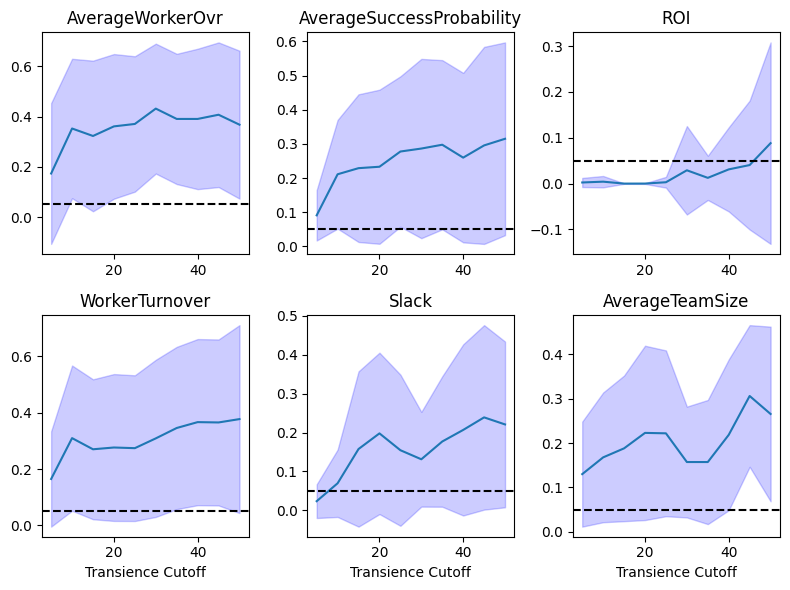

In [90]:
p_values = np.zeros((NUM_REPEATS, len(TRANSIENCE_CUTOFFS)))
adf_stats = np.zeros((NUM_REPEATS, len(TRANSIENCE_CUTOFFS)))

plt.figure(figsize=(8,6))
for pi, metric in enumerate(test_metrics):
    for i in range(NUM_REPEATS):
        for j, tr in enumerate(TRANSIENCE_CUTOFFS):
            X = model_data['greedy'][i][metric][tr:100]
            result = adfuller(X)
            p_values[i,j] = result[1]
            adf_stats[i,j] = result[0]
    
    plt.subplot(2,3,pi+1)
    plt.title(metric)
    plt.plot(TRANSIENCE_CUTOFFS, np.mean(p_values, axis=0))
    plt.fill_between(TRANSIENCE_CUTOFFS, np.mean(p_values, axis=0)-np.std(p_values, axis=0), np.mean(p_values, axis=0)+np.std(p_values, axis=0), color='b', alpha=0.2)
    # plt.plot(TRANSIENCE_CUTOFFS, np.mean(adf_stats, axis=0))
    plt.axhline(0.05, linestyle='--', color='k')

    if pi > 2:
        plt.xlabel('Transience Cutoff')

plt.tight_layout()

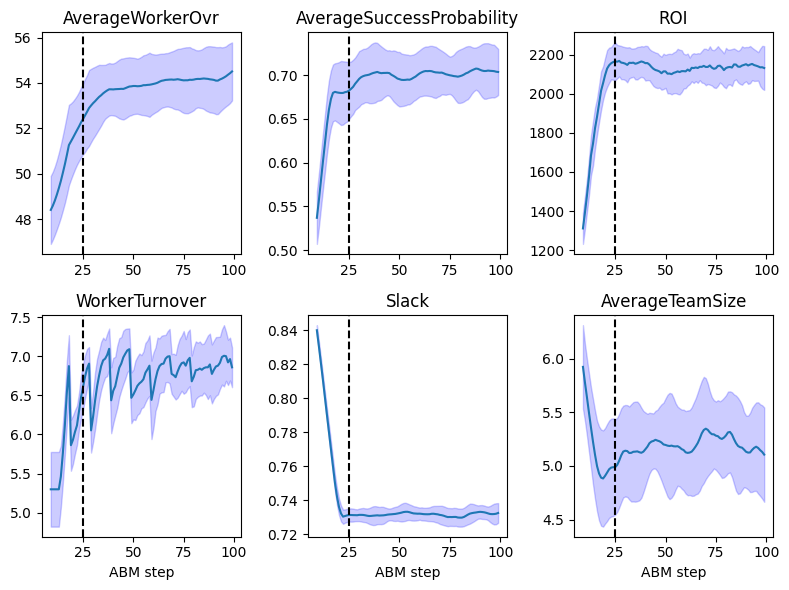

In [89]:
mav_length = 10
plt.figure(figsize=(8,6))

X = np.zeros((NUM_REPEATS, 100))
for pi, metric in enumerate(test_metrics):
    for i in range(NUM_REPEATS):
            X[i,:] = model_data['grasp'][i][metric].rolling(window=mav_length, center=False).mean()
    
    plt.subplot(2,3, pi+1)
    plt.title(metric)
    # plt.plot(X.rolling(window=mav_length, center=False).mean())
    plt.plot(X.mean(axis=0))
    plt.fill_between(range(100), np.mean(X, axis=0)-np.std(X, axis=0), np.mean(X, axis=0)+np.std(X, axis=0), color='b', alpha=0.2)
    plt.axvline(25, linestyle='--', color='k')

    if pi > 2:
        plt.xlabel('ABM step')


plt.tight_layout()

In [71]:
# model_data

In [101]:
def reconstruct_final_network(initial_net, network_dff, t=99):

    G = deepcopy(initial_net)
    t = str(t)
    for n in network_dff[t]['nodes_to_remove']:
        G.remove_node(str(n))
    for n in network_dff[t]['nodes_to_add']:
        G.add_node(str(n))
    for e in network_dff[t]['edges_to_add']:
        G.add_edge(e[0], e[1], weight=1)
    for e in network_dff[t]['edges_to_increment']:
        print('Increment!')
        G[e[0], e[1]]['weight'] += 1

    return G

In [102]:
def connectance(G, normalise=True, p=2, t=100, s=7):
    N = len(G.nodes)
    
    if not normalise:
        D = 1
    else:
        D = s*(s-1)*2*100 / (N*(N-1))

    C = len(G.edges()) / (N*(N-1))
    return C / D

# def connectance(G):
    # return len(max(nx.connected_components(G), key=len)) / len(G.nodes())

AverageWorkerOvr
random 49.4310316855186
greedy 49.45301725348115
grasp 49.45338119296625
rld2 (stochastic) 49.4478987078607
ensemble 49.45768944215833
AverageSuccessProbability
random 0.1468039130048299
greedy 0.47905862221696494
grasp 0.48576120501969144
rld2 (stochastic) 0.4437694366102008
ensemble 0.4897828511938665
ROI
random 1000.0
greedy 1000.0
grasp 1000.0
rld2 (stochastic) 1000.0
ensemble 1000.0
WorkerTurnover
random 0.0
greedy 0.0
grasp 0.0
rld2 (stochastic) 0.0
ensemble 0.0
Slack
random 0.8944736842105264
greedy 0.8853684210526316
grasp 0.884578947368421
rld2 (stochastic) 0.8844210526315791
ensemble 0.8814736842105264
AverageTeamSize
random 2.1052631578947367
greedy 6.078947368421052
grasp 6.2631578947368425
rld2 (stochastic) 4.368421052631579
ensemble 6.052631578947368


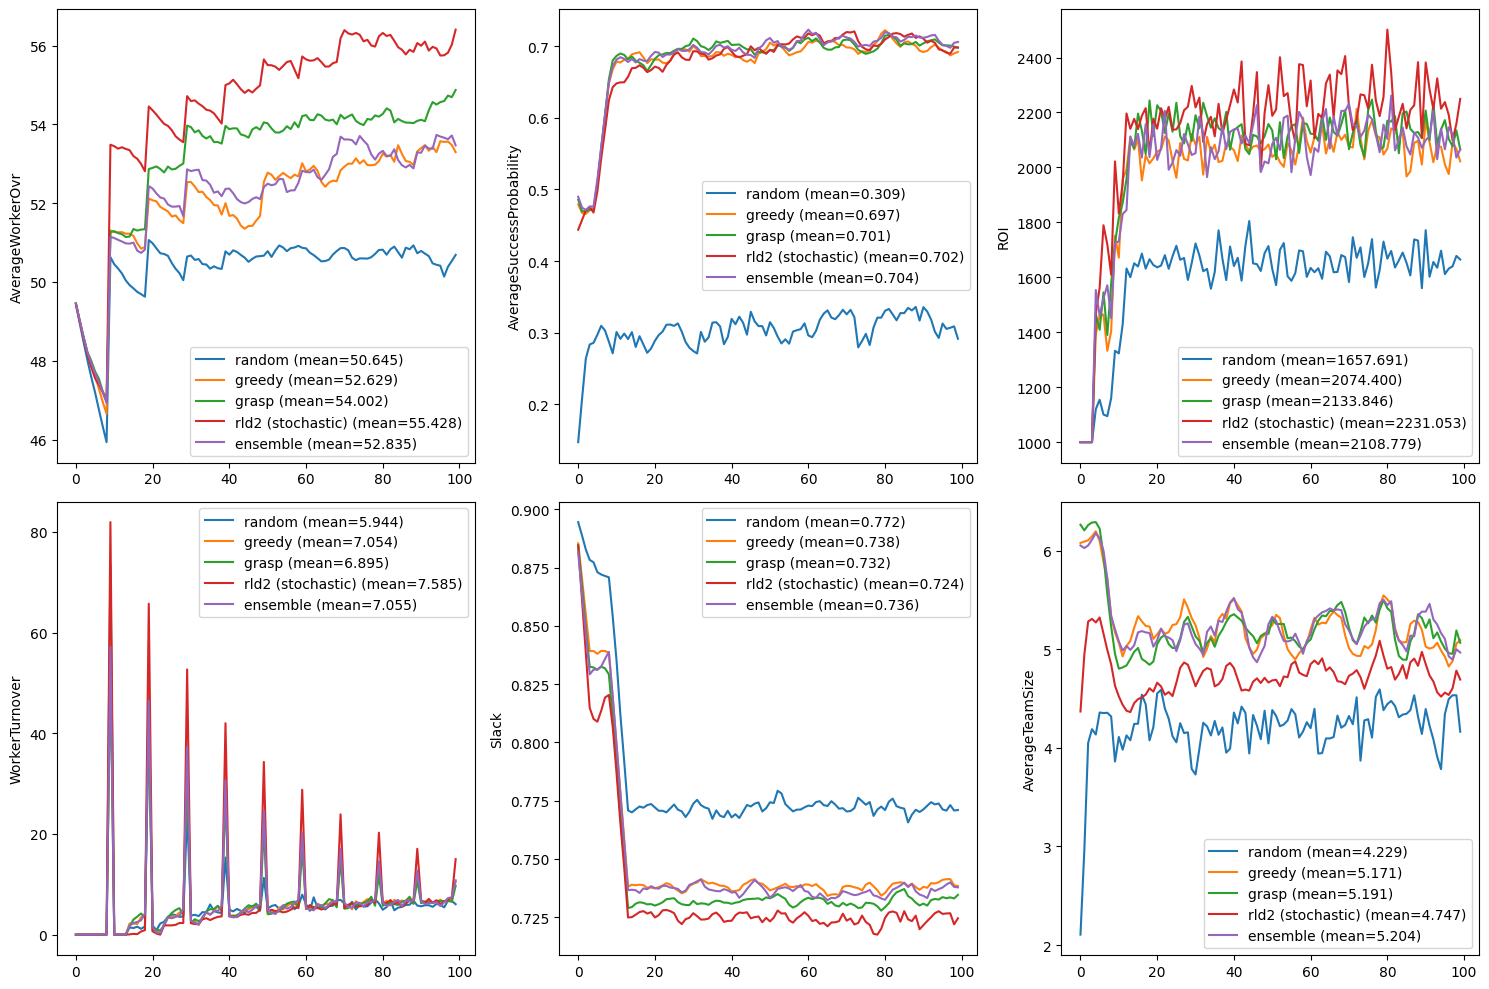

In [103]:
mean_values = {
    OBJECTIVE: {a: [] for a in algorithms.keys()},
}
# mean_values[OBJECTIVE] = {a: [] for a in algorithms.keys()}
variables = []
plt.figure(figsize=(15,10))
for pi, pv in enumerate([
    # 'AverageWorkerOvr', 'WorkerTurnover', 'Slack', 'ROI', 'AverageSuccessProbability', 'AverageTeamSize'
    # 'WorkerTurnover', 'AverageSuccessProbability'
    'AverageWorkerOvr', 'AverageSuccessProbability', 'ROI',
    'WorkerTurnover', 'Slack', 'AverageTeamSize'
]):
    plt.subplot(2,3,pi+1)
    print(pv)
    variables.append(pv)
    _mean_values = []
    
    for alg in algorithms.keys():
        if 'rld2' in alg:
            _NUM_REPEATS = NUM_RLD2_REPEATS
        else:
            _NUM_REPEATS = NUM_REPEATS

        mean_val = pd.concat([
                        model_data[alg][i][pv]
                        for i in range(_NUM_REPEATS)
                    ], axis=1).mean(axis=1)[START:].mean()
        mean_start_val = np.mean([
                        model_data[alg][i][pv][0]
                        for i in range(_NUM_REPEATS)
                    ])
        plt.plot(
            pd.concat([
                model_data[alg][i][pv]
                for i in range(_NUM_REPEATS)
            ], axis=1).mean(axis=1),
            label=alg + " (mean=%.3f)" % mean_val
        )
        print(
            alg, 
            mean_start_val,
         )
        mean_values[OBJECTIVE][alg].append(mean_val)
    
    plt.ylabel(pv)
    plt.legend()

    

plt.tight_layout()
plt.savefig(data_path / f"figures/stage_2_timeseries_{OBJECTIVE}.png")

#### Checking Ensemble outputs:

In [105]:
alg = 'ensemble'
projects = {}
for ni in range(_NUM_REPEATS):
    with open(algorithms[alg]['base'] / algorithms[alg]['path'] / algorithms[alg]['run_name'] / ('repeat_%d/abm_data_project_table.pickle' %ni), 'rb') as infile:
        projects[ni] = pickle.load(infile)


In [106]:
cp = projects[0].groupby('team_allocated_by').agg({'project_id':'count'}).rename(columns={'project_id':'count_0'})
for ni in range(_NUM_REPEATS-1):
    cp = pd.concat([cp, projects[ni+1].groupby('team_allocated_by').agg({'project_id':'count'}).rename(columns={'project_id':f"count_{ni+1}"})], axis=1)

In [107]:
cp.mean(axis=1)

team_allocated_by
grasp                      12.473684
greedy                    169.684211
reinforcement_learning      9.578947
dtype: float64

In [108]:
if 'network connectivity' not in variables:
    variables.append('network connectivity')
    
for alg in algorithms.keys():
    if 'rld2' in alg:
        _NUM_REPEATS = 7
    else:
        _NUM_REPEATS = NUM_REPEATS

    C = []
    for n in range(_NUM_REPEATS):
        G = reconstruct_final_network(networks[alg][n], network_diffs[alg][n])
        C.append(connectance(G))
    mean_values[OBJECTIVE][alg].append(np.mean(C))

KeyError: 'linear'

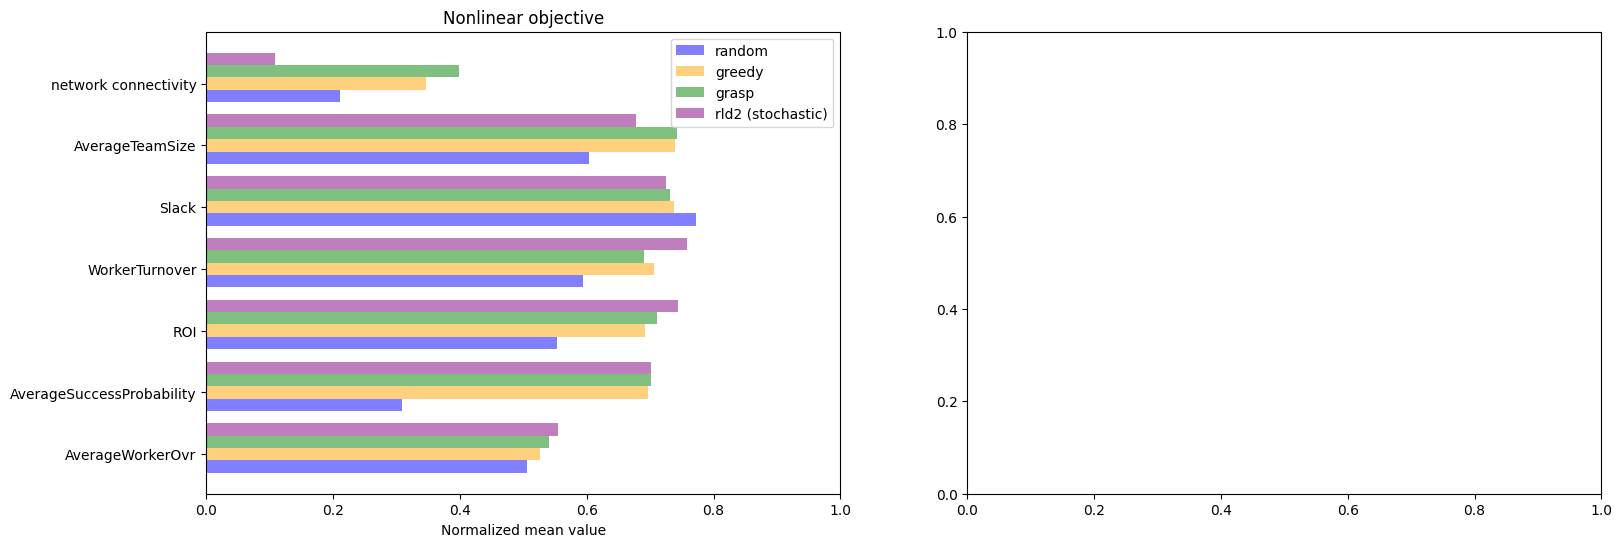

In [109]:
_alpha = 0.5

plt.figure(figsize=(18,6))
ax1 = plt.subplot(1,2,1)
x = np.arange(7) 

_mean_values = deepcopy(mean_values['nonlinear'])
for k in _mean_values.keys():
    _mean_values[k][0] /= 100
    _mean_values[k][2] /= 3000
    _mean_values[k][3] /= 10
    _mean_values[k][5] /= 7
    _mean_values[k][6] /= 0.1

y1 = _mean_values['random']
y2 = _mean_values['greedy']
y3 = _mean_values['grasp']
y4 = _mean_values['rld2 (stochastic)']
width = 0.2
  
# plot data in grouped manner of bar type 
plt.barh(x-0.2, y1, width, color='blue', alpha=_alpha) 
plt.barh(x, y2, width, color='orange', alpha=_alpha) 
plt.barh(x+0.2, y3, width, color='green', alpha=_alpha) 
plt.barh(x+0.4, y4, width, color='purple', alpha=_alpha) 
plt.yticks(x, variables, rotation=0) 
plt.xlabel("Normalized mean value") 
plt.title("Nonlinear objective")
plt.legend(algorithms.keys()) 
plt.xlim([0,1])

ax2 = plt.subplot(1,2,2)# sharey=ax1)

_mean_values = deepcopy(mean_values['linear'])
for k in _mean_values.keys():
    _mean_values[k][0] /= 100
    _mean_values[k][2] /= 3000
    _mean_values[k][3] /= 10
    _mean_values[k][5] /= 7
    _mean_values[k][6] /= 0.1
y1 = _mean_values['random']
y2 = _mean_values['greedy']
y3 = _mean_values['grasp']
y4 = _mean_values['rld2 (stochastic)']
width = 0.2
  
# plot data in grouped manner of bar type 
plt.barh(x-0.2, y1, width, color='blue', alpha=_alpha) 
plt.barh(x, y2, width, color='orange', alpha=_alpha) 
plt.barh(x+0.2, y3, width, color='green', alpha=_alpha) 
plt.barh(x+0.4, y4, width, color='purple', alpha=_alpha) 
plt.yticks(x, [], rotation=0) 
plt.xlabel("Normalized mean value") 
plt.title("Linear objective")
plt.legend(algorithms.keys()) 
plt.xlim([0,1])

plt.tight_layout()
plt.savefig(data_path / f"figures/stage_2_bar_comparison.png")

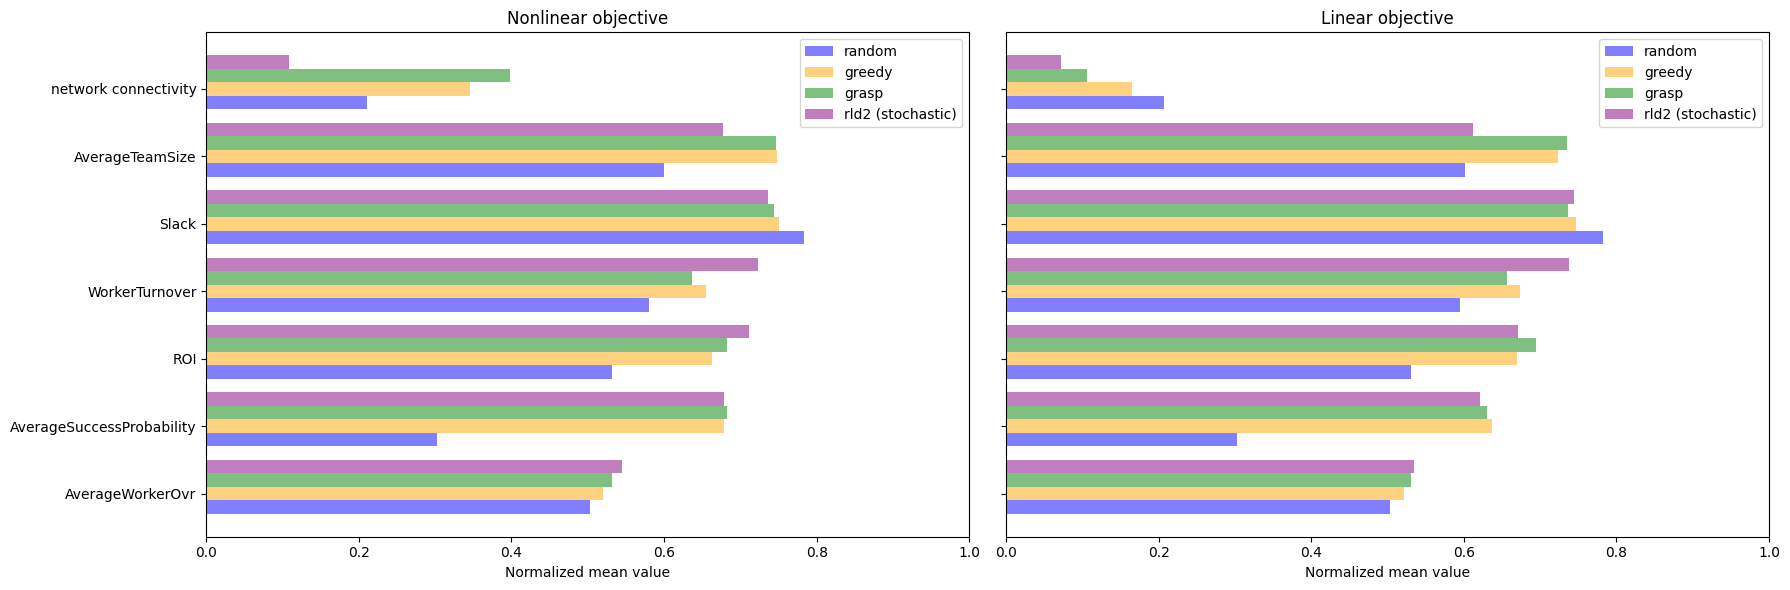

In [69]:
_alpha = 0.5

plt.figure(figsize=(18,6))
ax1 = plt.subplot(1,2,1)
x = np.arange(7) 

_mean_values = deepcopy(mean_values['nonlinear'])
for k in _mean_values.keys():
    _mean_values[k][0] /= 100
    _mean_values[k][2] /= 3000
    _mean_values[k][3] /= 10
    _mean_values[k][5] /= 7
    _mean_values[k][6] /= 0.1

y1 = _mean_values['random']
y2 = _mean_values['greedy']
y3 = _mean_values['grasp']
y4 = _mean_values['rld2 (stochastic)']
width = 0.2
  
# plot data in grouped manner of bar type 
plt.barh(x-0.2, y1, width, color='blue', alpha=_alpha) 
plt.barh(x, y2, width, color='orange', alpha=_alpha) 
plt.barh(x+0.2, y3, width, color='green', alpha=_alpha) 
plt.barh(x+0.4, y4, width, color='purple', alpha=_alpha) 
plt.yticks(x, variables, rotation=0) 
plt.xlabel("Normalized mean value") 
plt.title("Nonlinear objective")
plt.legend(algorithms.keys()) 
plt.xlim([0,1])

ax2 = plt.subplot(1,2,2)# sharey=ax1)

_mean_values = deepcopy(mean_values['linear'])
for k in _mean_values.keys():
    _mean_values[k][0] /= 100
    _mean_values[k][2] /= 3000
    _mean_values[k][3] /= 10
    _mean_values[k][5] /= 7
    _mean_values[k][6] /= 0.1
y1 = _mean_values['random']
y2 = _mean_values['greedy']
y3 = _mean_values['grasp']
y4 = _mean_values['rld2 (stochastic)']
width = 0.2
  
# plot data in grouped manner of bar type 
plt.barh(x-0.2, y1, width, color='blue', alpha=_alpha) 
plt.barh(x, y2, width, color='orange', alpha=_alpha) 
plt.barh(x+0.2, y3, width, color='green', alpha=_alpha) 
plt.barh(x+0.4, y4, width, color='purple', alpha=_alpha) 
plt.yticks(x, [], rotation=0) 
plt.xlabel("Normalized mean value") 
plt.title("Linear objective")
plt.legend(algorithms.keys()) 
plt.xlim([0,1])

plt.tight_layout()
plt.savefig(data_path / f"figures/stage_2_bar_comparison.png")

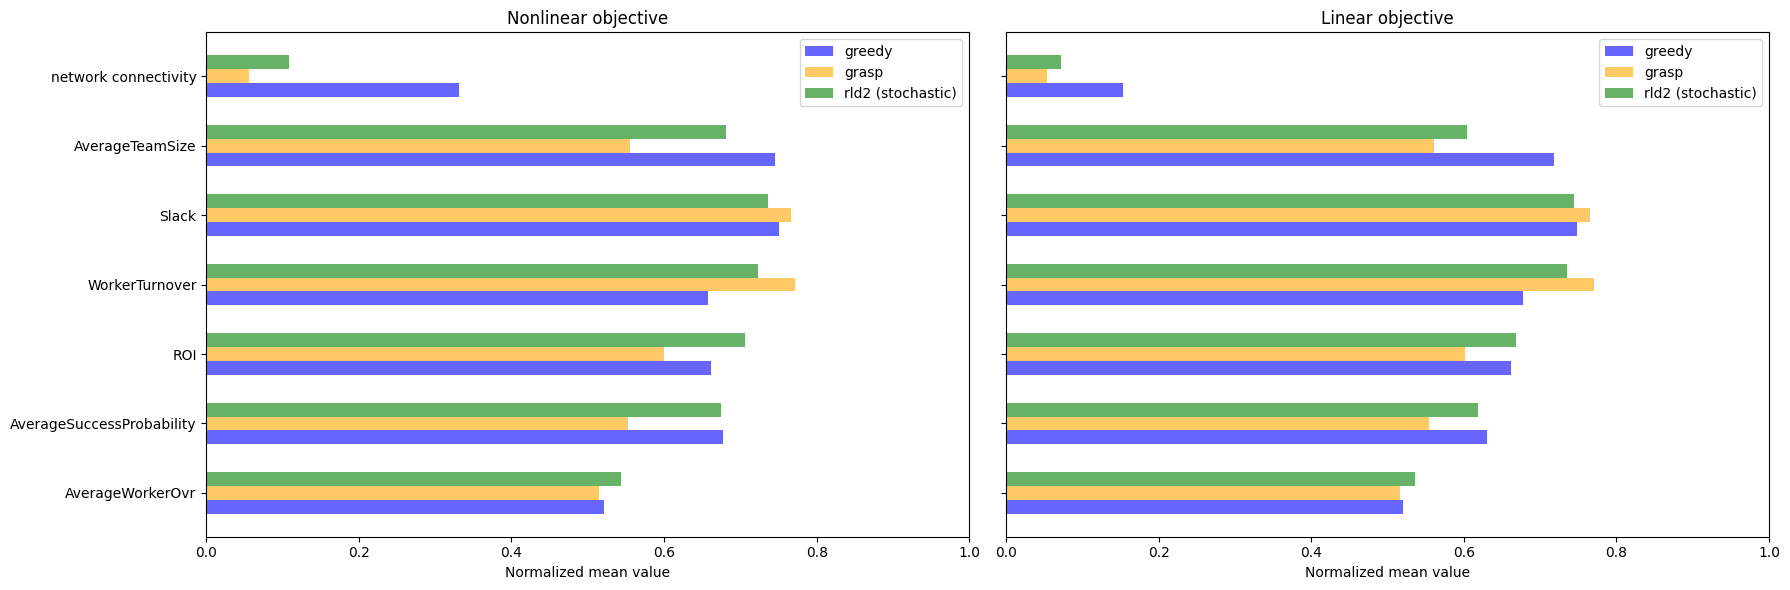

In [299]:
_alpha = 0.6 

plt.figure(figsize=(18,6))
ax1 = plt.subplot(1,2,1)
x = np.arange(7) 

_mean_values = deepcopy(mean_values['nonlinear'])
for k in _mean_values.keys():
    _mean_values[k][0] /= 100
    _mean_values[k][2] /= 3000
    _mean_values[k][3] /= 10
    _mean_values[k][5] /= 7
    _mean_values[k][6] /= 0.1
y1 = _mean_values['greedy']
y2 = _mean_values['grasp']
y3 = _mean_values['rld2 (stochastic)']
width = 0.2
  
# plot data in grouped manner of bar type 
plt.barh(x-0.2, y1, width, color='blue', alpha=_alpha) 
plt.barh(x, y2, width, color='orange', alpha=_alpha) 
plt.barh(x+0.2, y3, width, color='green', alpha=_alpha) 
plt.yticks(x, variables, rotation=0) 
plt.xlabel("Normalized mean value") 
plt.title("Nonlinear objective")
plt.legend(algorithms.keys()) 
plt.xlim([0,1])

ax2 = plt.subplot(1,2,2)# sharey=ax1)

_mean_values = deepcopy(mean_values['linear'])
for k in _mean_values.keys():
    _mean_values[k][0] /= 100
    _mean_values[k][2] /= 3000
    _mean_values[k][3] /= 10
    _mean_values[k][5] /= 7
    _mean_values[k][6] /= 0.1
y1 = _mean_values['greedy']
y2 = _mean_values['grasp']
y3 = _mean_values['rld2 (stochastic)']
width = 0.2
  
# plot data in grouped manner of bar type 
plt.barh(x-0.2, y1, width, color='blue', alpha=_alpha) 
plt.barh(x, y2, width, color='orange', alpha=_alpha) 
plt.barh(x+0.2, y3, width, color='green', alpha=_alpha) 
plt.yticks(x, [], rotation=0) 
plt.xlabel("Normalized mean value") 
plt.title("Linear objective")
plt.legend(algorithms.keys()) 
plt.xlim([0,1])

plt.tight_layout()
plt.savefig(data_path / f"figures/stage_2_bar_comparison.png")

In [158]:
# run_name = 'stage_2_20_workers_linear/rld2_100_10_run_2'
run_name = 'stage_2_100_workers_linear/greedy_run_0'

In [159]:
# plt.plot(df.AverageWorkerOvr)

In [160]:
with open(data_path / run_name / 'repeat_0/abm_data_project_table.pickle', 'rb') as infile:
    pdf = pickle.load(infile)

In [161]:
pdf.null.sum()

0

In [ ]:
with open(data_path / run_name / 'repeat_0/abm_data_agent_variables.pickle', 'rb') as infile:
    adf = pickle.load(infile)

In [ ]:
adf